# SVM (Support Vector Machine)

1. Why we need SVM?<br>
a.Complex data Seperation<br>
b.Classification Problems<br>
c.Binary Classification<br>
Ex: Spam vs Not spam, Disease vs No Disease<br>
<br>
2. Problem with Logistic Regression?<br>
Logistic Reg is works well when data is linearly seperable<br>
-- But what if data is complex<br>
-- Classes overlap<br>
-- Decision boundary is not straight<br> 
-- That is where SVM becomes powerful<br>
<br>
SVM is 2 types Classification and Regression<br>
-- Maximum distance is considered for the hyperplane because it covers more data points and is less likely to be affected by noise<br>
-- Soft Margin -> data points inbetween the hyperplane is called soft margin<br>
-- Hard Margin -> data points outside the hyperplane is called hard margin and perfectly seperable<br>
-- Kernal is used when data is not linearly seperable.Types-> Linear, Polynomial, RBF<br> 
-- Mainly uses RBF(Radial Basis Function)<br>
-- RBF is used when data is not linearly seperable<br>
-- Support vectors are the data points that are closest to the hyperplane in a Support Vector Machine (SVM).<br>
-- Hyperplane is a decision boundary that separates different classes in a Support Vector Machine (SVM).<br>
-- Decision boundary is the line or surface that separates different classes in a classification problem.<br>
<br>
y = mx + c
-- m and c values are derived from the data<br>
-- Parameters are values that are learned from data (m&c)<br>
-- Hyperparameters are input parameters which we pass to our models which are not related to data,These are not dependent on data only parameters are dependent on data<br>
-- For each and every algo each input parameters(Hyperparameters) are changed for best result<br>
-- To check which hyperparameters are best fro model we use GridSearchCV and RandomizedSearchCV<br>
-- Difference between GridSearchCV and RandomizedSearchCV is GridSearchCV tries all possible combinations of hyperparameter values.<br>


In [77]:
w=2
x=3
b=-4
y=w*x+b
print(y)
if y>0:
    print("Class 1")
else:
    print("Class 0")

2
Class 1


In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [100]:
df=pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [63]:
df.isna().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [64]:
df.shape

(891, 12)

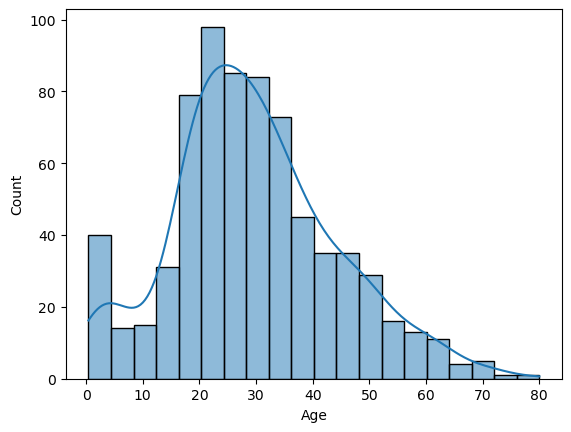

In [65]:
sns.histplot(df['Age'], kde=True)
plt.show()

In [101]:
df=df.fillna(df['Age'].median())

In [102]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


In [68]:
#df.drop(columns=['Cabin'], inplace=True)

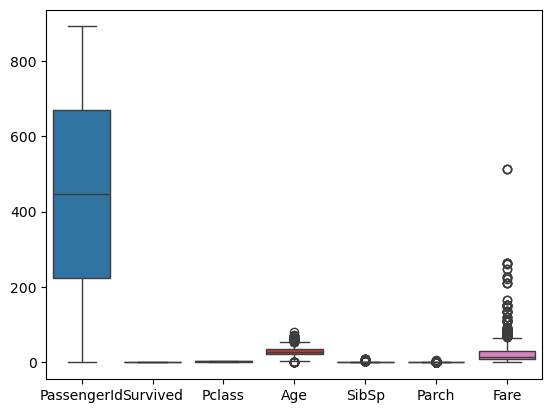

In [103]:
sns.boxplot(df)
plt.show()

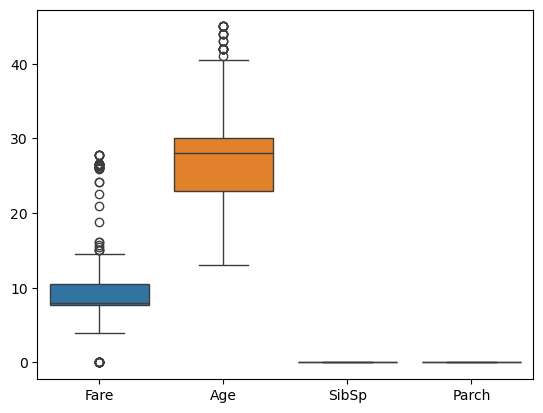

In [106]:
mask = pd.Series(True, index=df.index)
for col in ['Fare', 'Age', 'SibSp', 'Parch']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask &= (df[col] >= lower_bound) & (df[col] <= upper_bound)

df = df[mask].copy()

# Drop unused columns
cols_to_drop = [c for c in ['PassengerId', 'Name', 'Ticket', 'Cabin'] if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

# Encode categorical variables
if 'Sex' in df.columns:
    df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})
if 'Embarked' in df.columns:
    df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

sns.boxplot(data=df[['Fare', 'Age', 'SibSp', 'Parch']])
plt.show()


In [105]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Use the cleaned Titanic dataframe for features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Ensure only numeric features are passed to SVM
X = X.select_dtypes(include=[np.number])
print('X shape:', X.shape)
print('y shape:', y.shape)
print('X columns:', X.columns.tolist())
print('Missing values in X before imputation:')
print(X.isna().sum())

# Fill any remaining numeric NaN values before fitting
X = X.fillna(X.median())
print('Missing values in X after imputation:')
print(X.isna().sum())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Create an SVM model
svm_classifier = SVC(
    kernel='rbf',   # Type of boundary
    C=1.0,          # Regularization parameter
    gamma='scale'   # Controls the influence of data points
)

# Train the model
svm_classifier.fit(X_train, y_train)

# Make predictions
y_pred = svm_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")


X shape: (577, 6)
y shape: (577,)
X columns: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
Missing values in X before imputation:
Pclass    0
Sex       0
Age       0
SibSp     0
Parch     0
Fare      0
dtype: int64
Missing values in X after imputation:
Pclass    0
Sex       0
Age       0
SibSp     0
Parch     0
Fare      0
dtype: int64
Accuracy: 0.72


# Types of Kernals
1. Linear = Linear data<br>
2. poly = Polynomial relationship<br>
3. RBF = Curved or Non linear complex data<br>
4. sigmoid = Neural-network-like behavior<br>

c = 1 # Regularization parameter(It controls underfitting and overfitting)<br>
small c --> wider margin --> Underfitting<br>
large c --> narrow margin --> Overfitting<br>
